In [1]:
!git clone https://github.com/Break-Through-Tech/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression.git

Cloning into 'MathWorks-1C-unlocking-embedded-ai-through-efficient-compression'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 64 (delta 19), reused 31 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 19.21 MiB | 18.70 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [2]:
%cd MathWorks-1C-unlocking-embedded-ai-through-efficient-compression

/content/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression


In [3]:
!pwd
!ls

/content/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression
Challenge-Project-Overview.md	notebooks	  src
data				README.md
Getting-Started-for-Fellows.md	requirements.txt


In [4]:
# ── Environment Check ──────────────────────────────────────
# Confirms everyone on the team loads the same data, sees the
# same shapes/counts, before splitting into individual work.

import scipy.io
import numpy as np
from collections import Counter

SEED = 42
np.random.seed(SEED)

base = "data"  # adjust path if running outside the repo root

train = scipy.io.loadmat(f"{base}/train.mat")
val   = scipy.io.loadmat(f"{base}/val.mat")
test  = scipy.io.loadmat(f"{base}/test.mat")

X_train = train['trainData']
y_train = np.array([label[0] for label in train["trainLabels"].flatten()])

X_val = val['valData']
y_val = np.array([label[0] for label in val["valLabels"].flatten()])

X_test = test['testData']
y_test = np.array([label[0] for label in test["testLabels"].flatten()])

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Counts:", len(y_train), len(y_val), len(y_test))
print("Train class balance:", Counter(y_train))
print("Val class balance:", Counter(y_val))
print("Test class balance:", Counter(y_test))

assert X_train.shape == (393, 5000)
assert X_val.shape == (27, 5000)
assert X_test.shape == (102, 5000)
assert Counter(y_train) == Counter({'Normal': 131, 'InnerRaceFault': 131, 'OuterRaceFault': 131})
print("\n✅ Data matches spec — environment check passed.")

Shapes: (393, 5000) (27, 5000) (102, 5000)
Counts: 393 27 102
Train class balance: Counter({np.str_('InnerRaceFault'): 131, np.str_('OuterRaceFault'): 131, np.str_('Normal'): 131})
Val class balance: Counter({np.str_('InnerRaceFault'): 9, np.str_('OuterRaceFault'): 9, np.str_('Normal'): 9})
Test class balance: Counter({np.str_('InnerRaceFault'): 34, np.str_('OuterRaceFault'): 34, np.str_('Normal'): 34})

✅ Data matches spec — environment check passed.


## 1. Signal Magnitude Metrics

To compare vibration magnitude across bearing classes, three metrics are calculated for each 5,000-sample window:

- **RMS (Root Mean Square):** measures the overall magnitude of the vibration signal.
- **Standard Deviation:** measures how much the vibration fluctuates around its mean.
- **Peak Amplitude:** measures the largest absolute vibration value in the window.

These metrics are used to determine whether the three bearing classes contain meaningful vibration magnitude differences between them before and after standardization.

In [5]:
# Calculate signal-magnitude metrics for every training window.
# Each row of X_train is one 5,000-sample vibration signal
# axis = 1 performs each calculation across the 5,000 measurements within a window.

def rms(x):
    # RMS (Root Mean Square) measures the overall magnitude of a signal.
    return np.sqrt(np.mean(x**2, axis=1))

def peak_amplitude(x):
    # Peak amplitude measures the largest absolute vibration measurement per window.
    return np.max(np.abs(x), axis=1)

# Produce one RMS, standard deviation, and peak value for each training window.
raw_rms = rms(X_train)
raw_std = np.std(X_train, axis=1)
raw_peak = peak_amplitude(X_train)

In [6]:
# Get the three unique bearing-condition labels so results can be summarized by class.
classes = np.unique(y_train)

# Summarize the raw vibration metrics separately for each bearing class.
# The Boolean mask selects only the training windows belonging to the current class.
# Taking the mean for a simple class-level comparison of vibration magnitude.

for cls in classes:
    mask = y_train == cls

    print(f"\n{cls}")
    print("Mean RMS:", raw_rms[mask].mean())
    print("Mean STD:", raw_std[mask].mean())
    print("Mean peak amplitude:", raw_peak[mask].mean())


InnerRaceFault
Mean RMS: 1.886075914788693
Mean STD: 1.873487326408376
Mean peak amplitude: 22.453814503816794

Normal
Mean RMS: 0.7770882237604496
Mean STD: 0.7693852404855761
Mean peak amplitude: 3.0329826911550315

OuterRaceFault
Mean RMS: 0.8821165422687993
Mean STD: 0.8698524652114309
Mean peak amplitude: 5.4102790275249575


## 2. Global Train-Set Standardization

Global standardization calculates one mean and one standard deviation from the entire training set. These same training statistics are then used to standardize the training, validation, and test sets.

Because every vibration window is transformed using the same scale, differences in vibration magnitude between windows are preserved.

In [7]:
# Calculate one mean and one standard deviation using all vibration values in the training set.
# They are the shared scaling parameters used for global standardization.

train_mean = X_train.mean()
train_std = X_train.std()

# Standardize every value using the same training-set mean and standard deviation.
# Using the same scale for every window preserves relative differences

X_train_global = (X_train - train_mean) / train_std
X_val_global = (X_val - train_mean) / train_std
X_test_global = (X_test - train_mean) / train_std

# Display the global training statistics used for the transformation.

print(train_mean, train_std)

-0.1537873379955809 1.2870536466273186


In [8]:
# Recalculate the same vibration metrics after global standardization.
# Use to compare the transformed signals with the original raw signals
# and determine whether class-level amplitude differences were preserved.

global_rms = rms(X_train_global)
global_std = np.std(X_train_global, axis=1)
global_peak = peak_amplitude(X_train_global)

# Summarize the globally standardized metrics by bearing class.
for cls in classes:
    mask = y_train == cls

    print(f"\n{cls}")
    print("Mean RMS:", global_rms[mask].mean())
    print("Mean STD:", global_std[mask].mean())
    print("Mean peak amplitude:", global_peak[mask].mean())


InnerRaceFault
Mean RMS: 1.4564860272244022
Mean STD: 1.455640432174515
Mean peak amplitude: 17.49662370682885

Normal
Mean RMS: 0.5997085250241553
Mean STD: 0.597788011790903
Mean peak amplitude: 2.3379383231478315

OuterRaceFault
Mean RMS: 0.6764278827207324
Mean STD: 0.6758478696601735
Mean peak amplitude: 4.205393232758786


## 3. Per-Window Standardization

Per-window standardization calculates a separate mean and standard deviation for each individual 5,000-sample vibration window.

This forces every window to approximately zero mean and unit variance, removing differences in overall vibration magnitude between windows while preserving relative patterns within each signal.

In [9]:
# Calculate a separate mean and standard deviation for every individual vibration window.
# axis=1 means each row is treated independently.
# keepdims=True keeps the result shaped as (N, 1), which allows NumPy
# to subtract one mean from all 5,000 samples in the matching window.

def standardize_per_window(X):
    means = X.mean(axis=1, keepdims=True)
    stds = X.std(axis=1, keepdims=True)

    # Center every window around zero and divide by its own standard deviation.
    return (X - means) / stds


# Apply the same per-window procedure independently to each dataset split.
# Unlike global standardization, there are no shared train-set scaling values

X_train_window = standardize_per_window(X_train)
X_val_window = standardize_per_window(X_val)
X_test_window = standardize_per_window(X_test)

In [10]:
# Recalculate vibration metrics after per-window standardization.
# Peak amplitude can still differ because unusually large spikes relative
# to the rest of the same signal are not removed by this transformation.

window_rms = rms(X_train_window)
window_std = np.std(X_train_window, axis=1)
window_peak = peak_amplitude(X_train_window)

# Summarize the per-window standardized metrics by class.
for cls in classes:
    mask = y_train == cls

    print(f"\n{cls}")
    print("Mean RMS:", window_rms[mask].mean())
    print("Mean STD:", window_std[mask].mean())
    print("Mean peak amplitude:", window_peak[mask].mean())


InnerRaceFault
Mean RMS: 0.9999999999999998
Mean STD: 0.9999999999999998
Mean peak amplitude: 12.040821169347787

Normal
Mean RMS: 1.0
Mean STD: 1.0
Mean peak amplitude: 3.907059500480519

OuterRaceFault
Mean RMS: 1.0
Mean STD: 1.0
Mean peak amplitude: 5.87249053146064


## 4. Class-Level Comparison

The table summarizes the average RMS, standard deviation and peak amplitude for each bearing class under the raw, globally standardized, and per-window standardized conditions.

In [19]:
import pandas as pd

# Build one summary row for each bearing class.

rows = []

for cls in classes:
    mask = y_train == cls

    rows.append({
        "class": cls,

        # RMS comparison
        "raw_rms": raw_rms[mask].mean(),
        "global_rms": global_rms[mask].mean(),
        "per_window_rms": window_rms[mask].mean(),

        # Standard-deviation comparison
        "raw_std": raw_std[mask].mean(),
        "global_std": global_std[mask].mean(),
        "per_window_std": window_std[mask].mean(),

        # Peak-amplitude comparison
        "raw_peak": raw_peak[mask].mean(),
        "global_peak": global_peak[mask].mean(),
        "per_window_peak": window_peak[mask].mean()
    })

# Convert the collected class summaries into a DataFrame
comparison = pd.DataFrame(rows)

comparison

,class,raw_rms,global_rms,per_window_rms,raw_std,global_std,per_window_std,raw_peak,global_peak,per_window_peak
0,InnerRaceFault,1.886076,1.456486,1.0,1.873487,1.455640,1.0,22.453815,17.496624,12.040821
1,Normal,0.777088,0.599709,1.0,0.769385,0.597788,1.0,3.032983,2.337938,3.907060
2,OuterRaceFault,0.882117,0.676428,1.0,0.869852,0.675848,1.0,5.410279,4.205393,5.872491


## 5. Raw Vibration Distributions by Class

Class averages can hide variation between individual vibration windows. These boxplots show the distributions of RMS, standard deviation, and peak amplitude within each class.

This helps determine whether the observed magnitude differences are consistent across the dataset or driven by only a small number of extreme windows.

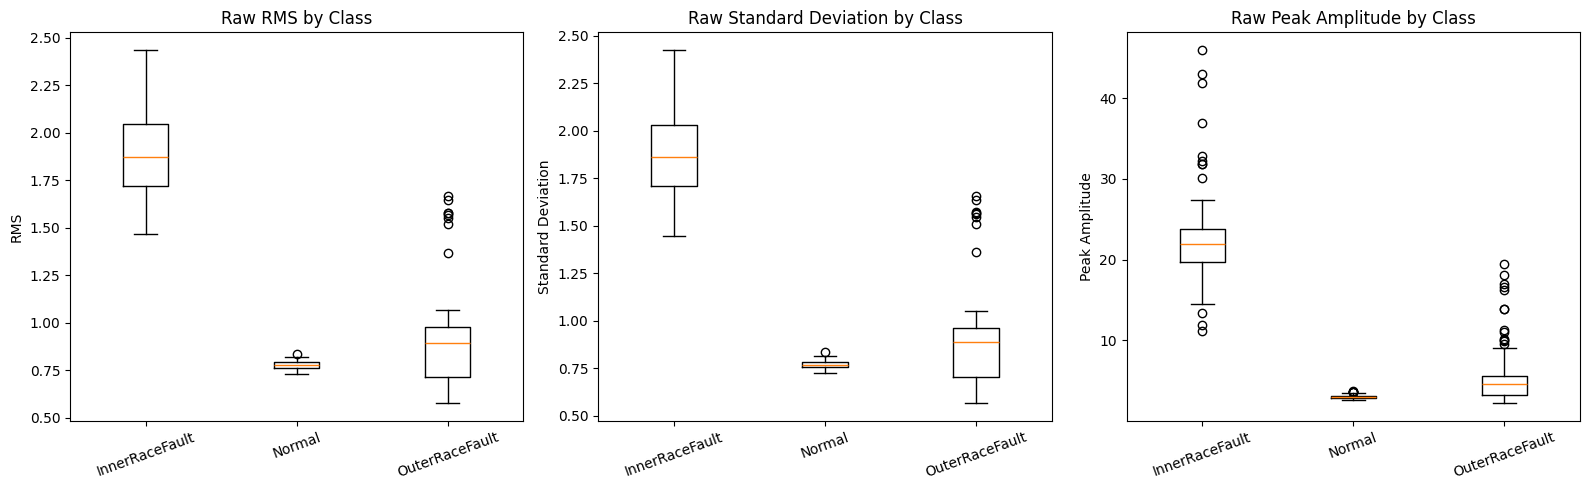

In [17]:
# Compare the DISTRIBUTION of raw vibration metrics across classes.
# Boxplots show how individual windows are distributed, including the median, spread, and potential outliers.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pair each per-window metric array with the label used on its plot.
metrics = [
    (raw_rms, "RMS"),
    (raw_std, "Standard Deviation"),
    (raw_peak, "Peak Amplitude")
]

# Create one array of metric values for each bearing class.
for ax, (values, title) in zip(axes, metrics):
    data_by_class = [
        values[y_train == cls]
        for cls in classes
    ]

    #Draw the boxplot
    ax.boxplot(data_by_class, tick_labels=classes)
    ax.set_title(f"Raw {title} by Class")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. Effect of Standardization on Class Distributions

The following plots compare the raw, globally standardized, and per-window standardized distributions for RMS, standard deviation, and peak amplitude.

The purpose is to determine which standardization approach preserves the original class-level amplitude information.

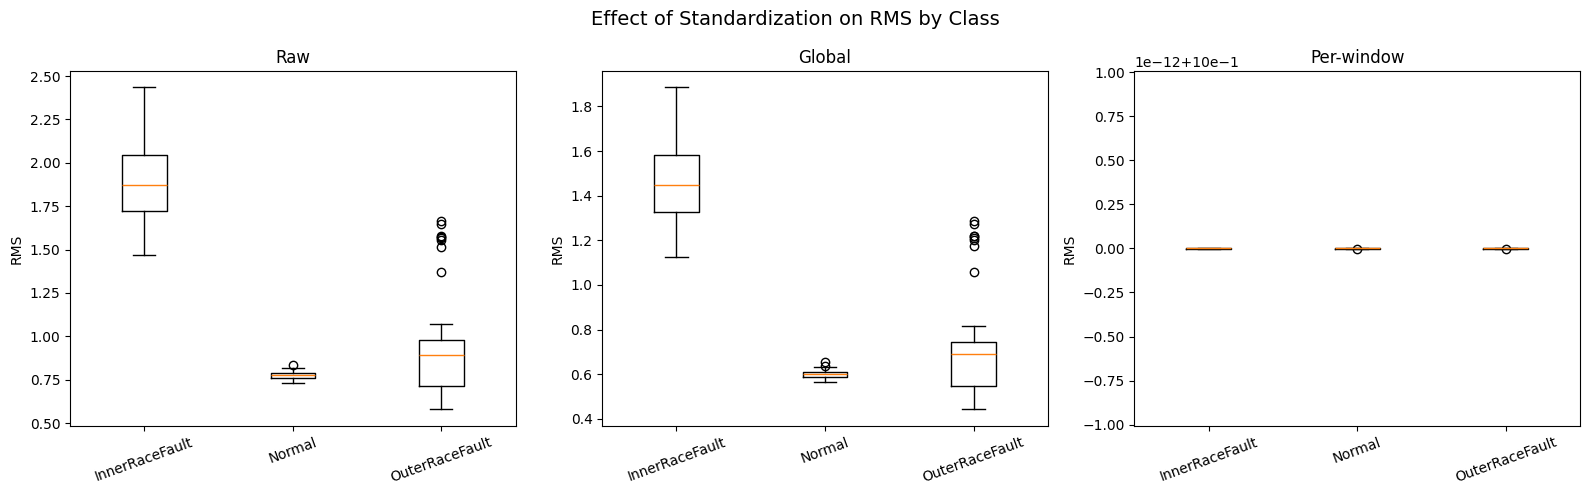

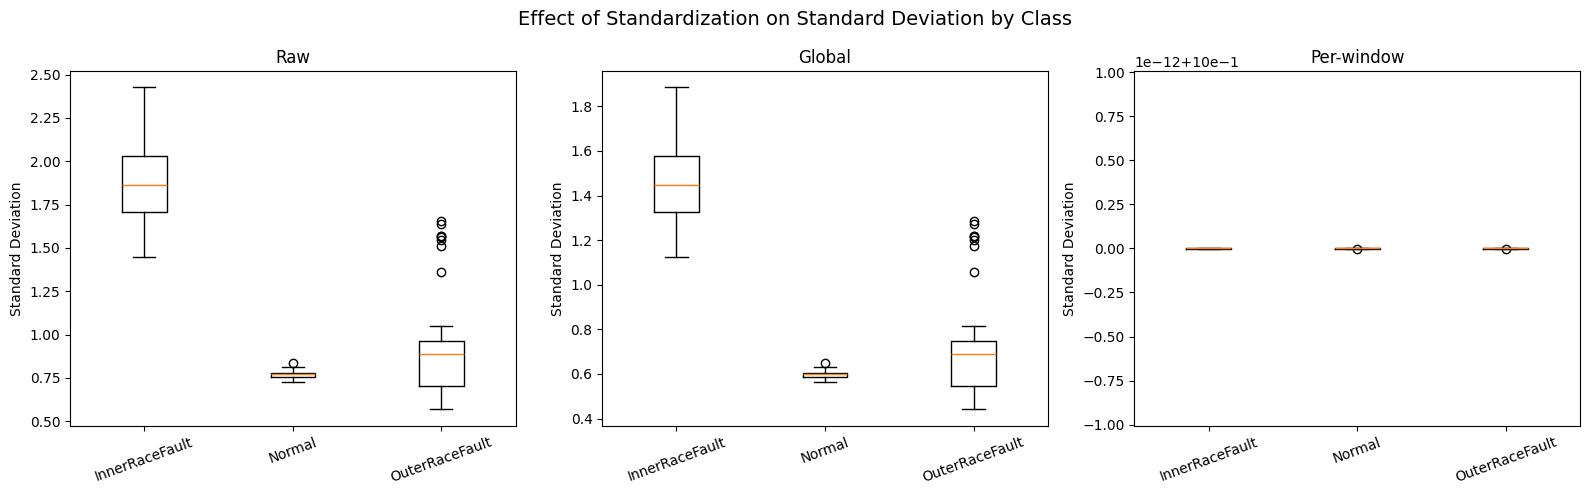

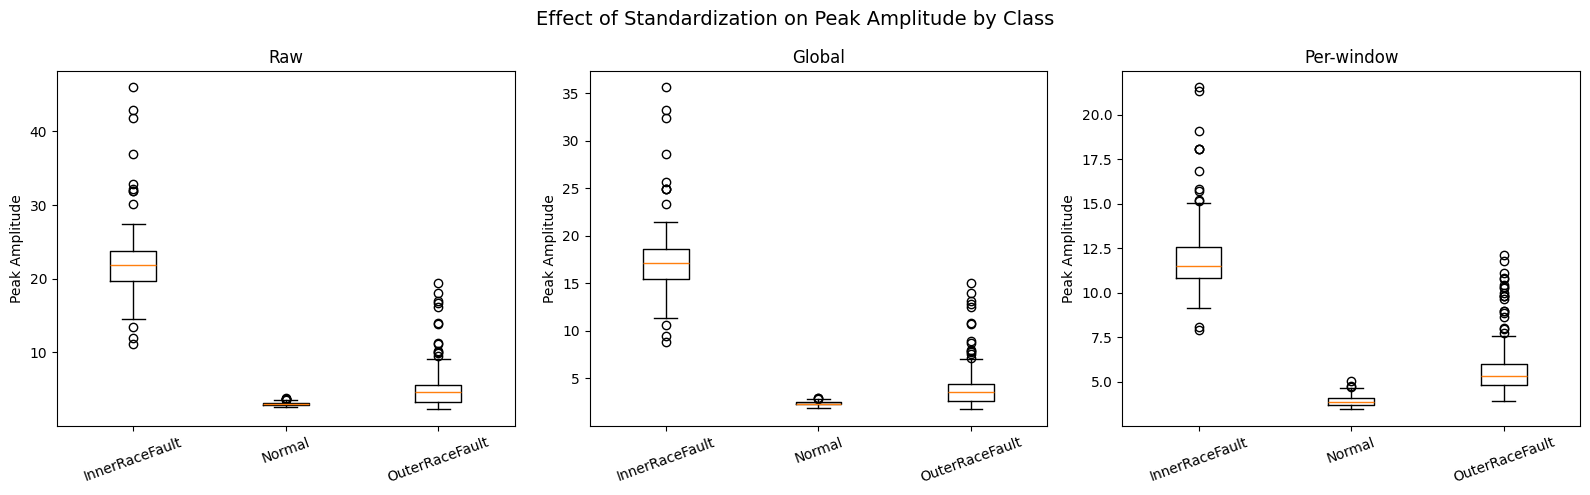

In [18]:
# Organize each vibration metric together with its raw, global-standardized and per-window-standardized versions.

metric_sets = {
    "RMS": {
        "Raw": raw_rms,
        "Global": global_rms,
        "Per-window": window_rms
    },
    "Standard Deviation": {
        "Raw": raw_std,
        "Global": global_std,
        "Per-window": window_std
    },
    "Peak Amplitude": {
        "Raw": raw_peak,
        "Global": global_peak,
        "Per-window": window_peak
    }
}

# Create one three-panel figure for each metric.

for metric_name, methods in metric_sets.items():

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

    for ax, (method_name, values) in zip(axes, methods.items()):

        # Separate the per-window metric values into the three bearing classes
        data_by_class = [
            values[y_train == cls]
            for cls in classes
        ]

        ax.boxplot(data_by_class, tick_labels=classes)
        ax.set_title(method_name)
        ax.set_ylabel(metric_name)
        ax.tick_params(axis="x", rotation=20)

    fig.suptitle(
        f"Effect of Standardization on {metric_name} by Class",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

# Final Conclusion

The training signals possess substantial differences in vibration magnitudes between classes. InnerRaceFault windows have consistently higher RMS, standard deviation, and peak amplitude compared to Normal and OuterRaceFault windows. OuterRaceFault also has a greater variability than Normal. Global standardization is able to preserve these amplitude differences while rescaling the data to a common scale. On the other hand, per-window standardization forces each window to approximately zero mean and unit variance, removing any RMS and standard deviation differences between classes. However, peak amplitude differences still remained after the per-window standardization, which indicates that relative impulsiveness still remains preserved. Based on the goal of retaining useful amplitude information, global standrdization is recommended for the preprocessing pipeline. The effect of this choice should be documented later during model training.

